<a href="https://colab.research.google.com/github/Eikthyrnir/uam-cv-sim-to-real-interpretability/blob/main/DIMO_sandbox.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Wizja komputerowa, dane syntetyczne i testowanie architektur

**Projekty dla studentów V roku / ostatniego semestru. Realizacja w parach dwuosobowych.**

# **Zasady ogólne**

**Każdy projekt jest realizowany przez dokładnie dwie osoby.** Temat ma prowadzić do kompletnego, mierzalnego eksperymentu z użyciem modeli wizyjnych: klasyfikacji, detekcji, segmentacji, pseudoetykietowania, samonadzorowanego uczenia reprezentacji albo analizy luki domenowej. Projekty mogą mocniej akcentować generowanie danych syntetycznych albo testowanie architektur, ale każdy projekt musi kończyć się wynikami ilościowymi i jakościowymi.

· Każda para musi udostępnić publiczne lub dostępne dla prowadzącego repozytorium GitHub z kodem, konfiguracjami, instrukcją uruchomienia, skryptami przygotowania danych i wynikami eksperymentów.

· Każda para musi przygotować dokument wynikowy, najlepiej w formacie PDF lub Google Docs, opisujący cel, dane, metody, architektury, eksperymenty, wyniki, wizualizacje, błędy i ograniczenia.

· Link do repozytorium oraz link do dokumentu wynikowego muszą zostać wpisane do arkusza Google Sheets: [arkusz projektów](https://docs.google.com/spreadsheets/d/1HeEo42lNxoAGrou7ehcJk4KBIXR4Gv7RgMd3FmzLE0I/edit?usp=sharing).

· W arkuszu powinny znaleźć się co najmniej: numer projektu, imiona i nazwiska studentów, link do repozytorium, link do raportu, link do danych/artefaktów/modeli, krótki opis finalnego wariantu eksperymentu oraz status projektu.

· Zbiory danych wskazane poniżej są publicznie dostępne lub powszechnie używane w badaniach. Przed użyciem należy sprawdzić i respektować licencję konkretnego zbioru, obrazu i adnotacji; nie wszystkie zbiory są stricte CC0/public domain.

# **Minimalny zakres wyników**

· Dla lżejszych projektów klasyfikacyjnych lub segmentacyjnych oczekiwane jest około 15-30 sensownych konfiguracji lub wariantów eksperymentalnych.

· Dla cięższych projektów detekcyjnych oczekiwane jest około 8-15 konfiguracji, ale z pełniejszą analizą kosztu obliczeniowego, błędów i transferu domenowego.

· Każdy projekt musi zawierać punkt odniesienia, warianty porównawcze, tabele metryk, wykresy, wizualizacje wyników, przykłady błędów oraz interpretowalność: Grad-CAM, mapy uwagi, aktywacje, filtry lub osadzenia.

· Raport powinien mieć strukturę krótkiego artykułu: wstęp i pytanie badawcze, przegląd literatury, opis danych, metoda, protokół eksperymentów, wyniki, analiza jakościowa, ograniczenia, wnioski i instrukcja reprodukcji.


## **7\. Co sieci naprawdę uczą się z danych syntetycznych? Aktywacje, filtry i skróty decyzyjne**

**Kierunek:** interpretowalność / testowanie architektur

**Zadanie wizyjne:** klasyfikacja lub detekcja

**Publicznie dostępne zbiory danych:** COCO, Open Images, własny zbiór Blender, RarePlanes

**Pytanie badawcze:** Czy model trenowany na syntetykach uczy się obiektu, czy raczej artefaktów renderingu, tła, tekstur i innych skrótów decyzyjnych?

**Opis projektu:** To projekt diagnostyczny. Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych. Następnie analizuje aktywacje warstw, mapy uwagi, Grad-CAM oraz przypadki błędów. Celem jest wykrycie, kiedy syntetyki tworzą bias tła, bias tekstury lub bias kształtu.

**Modele i metody do przetestowania:**

· ResNet/ConvNeXt dla klasyfikacji

· YOLOv10 lub Faster R-CNN dla detekcji

· ViT/DINOv2 dla analizy uwagi

**Wymagane eksperymenty:**

· porównanie 4-5 reżimów danych

· analiza wrażliwości na zasłanianie fragmentów obrazu: usuwanie tła, tekstury, części obiektu

· UMAP/t-SNE osadzeń cech dla danych rzeczywistych i syntetycznych

· analiza 50 poprawnych i 50 błędnych predykcji

**Wymagane wyniki i analiza:**

· dokładność lub mAP

· co najmniej 50 wizualizacji Grad-CAM / mapy uwagi

· mapy filtrów lub aktywacji wybranych warstw

· ranking najczęstszych skrótów decyzyjnych

· sekcja w raporcie: kiedy syntetyki pomagają, a kiedy szkodzą

**Linki:** [pytorch-grad-cam](https://github.com/jacobgil/pytorch-grad-cam); [DINOv2](https://github.com/facebookresearch/dinov2); [COCO](https://cocodataset.org/); [Open Images](https://storage.googleapis.com/openimages/web/index.html); [RarePlanes](https://www.iqt.org/library/the-rareplanes-dataset); [ConvNeXt V2](https://github.com/facebookresearch/ConvNeXt-V2)


## Step 1: Mount Google Drive
To avoid downloading massive files every time your session disconnects, we can save the dataset to Google Drive (if you have enough space). Otherwise, you can use the local `/content/` storage, but remember it will be cleared after the session ends.

In [33]:
from google.colab import drive
import os

# Mount Google Drive (Optional but recommended if you have space)
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Step 2: Download the Dataset

### Download from official DIMO links to Google Drive (Slow)

In [ ]:
PROJECT_DIR = '/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO'

os.makedirs(PROJECT_DIR, exist_ok=True)

In [ ]:
TAR_PATH = os.path.join(PROJECT_DIR, "dimo.tar")

In [ ]:
DATASET_URL = "https://datasets.ilabt.imec.be/dimo/tar/dimo.tar"


# Download only if it doesn't exist yet
if not os.path.exists(TAR_PATH):
    !wget -O "{TAR_PATH}" "{DATASET_URL}"

--2026-05-27 19:20:14--  https://datasets.ilabt.imec.be/dimo/tar/dimo.tar
Resolving datasets.ilabt.imec.be (datasets.ilabt.imec.be)... 193.191.148.201, 2001:6a8:1d80:26::201
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 14153728 (13M) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo.tar’

/content/drive/MyDr 100%[===================>]  13.50M  5.44MB/s    in 2.5s    

2026-05-27 19:20:18 (5.44 MB/s) - ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo.tar’ saved [14153728/14153728]



#### Download Real-World Data (RealSense D415)
Since the project involves comparing real and synthetic data, let's start with the smallest real-world image archive (RealSense D415, 12.7 GB). Replace the URL below with the actual link to this archive.

In [ ]:
REAL_DATA_URL = "https://datasets.ilabt.imec.be/dimo/tar/real_d415.tar"
REAL_TAR_PATH = os.path.join(PROJECT_DIR, "real_d415.tar")

if not os.path.exists(REAL_TAR_PATH):
    !wget -O "{REAL_TAR_PATH}" "{REAL_DATA_URL}"

#### Download dimo small

In [ ]:
REAL_DATA_URL = "https://datasets.ilabt.imec.be/dimo/tar/dimo_small.tar"
REAL_TAR_PATH = os.path.join(PROJECT_DIR, "dimo_small.tar")

if not os.path.exists(REAL_TAR_PATH):
    !wget -O "{REAL_TAR_PATH}" "{REAL_DATA_URL}"

--2026-05-28 13:15:38--  https://datasets.ilabt.imec.be/dimo/tar/dimo_small.tar
Resolving datasets.ilabt.imec.be (datasets.ilabt.imec.be)... 193.191.148.201, 2001:6a8:1d80:26::201
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 65892688896 (61G) [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo_small.tar’

/content/drive/MyDr   1%[                    ]   1.01G  9.15MB/s    in 97s     

2026-05-28 13:17:16 (10.6 MB/s) - Connection closed at byte 1080401777. Retrying.

--2026-05-28 13:17:17--  (try: 2)  https://datasets.ilabt.imec.be/dimo/tar/dimo_small.tar
Connecting to datasets.ilabt.imec.be (datasets.ilabt.imec.be)|193.191.148.201|:443... connected.
HTTP request sent, awaiting response... 206 Partial Content
Length: 65892688896 (61G), 64812287119 (60G) remaining [application/octet-stream]
Saving to: ‘/content/drive/MyDrive/UAM/Magister

### Download from Tim's Google Drive (much faster)

In [30]:
!mkdir /content/DIMO_archives

In [ ]:
# !gdown --id 1py7xaJpql7a6SrS9N5JF0xANLpbYZ4yM -O /content/DIMO_archives/dimo.tar

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1py7xaJpql7a6SrS9N5JF0xANLpbYZ4yM
To: /content/DIMO_archives/dimo.tar
100% 14.2M/14.2M [00:00<00:00, 81.7MB/s]


In [ ]:
# !gdown --id 1TyINalV-nfdbbalOzcebp4tH9_K-ibI5 -O /content/DIMO_archives/real_d415.tar

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1TyINalV-nfdbbalOzcebp4tH9_K-ibI5
From (redirected): https://drive.google.com/uc?id=1TyINalV-nfdbbalOzcebp4tH9_K-ibI5&confirm=t&uuid=d9e7b407-441f-4897-8452-d57a85995fc6
To: /content/DIMO_archives/real_d415.tar
100% 12.7G/12.7G [02:55<00:00, 72.6MB/s]


In [31]:
!gdown --id 1xCHhENLfAZDgOErz4TWL-FhMBnJ8uhVO -O /content/DIMO_archives/dimo_small.tar

/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Failed to retrieve file url:

	Too many users have viewed or downloaded this file recently. Please
	try accessing the file again later. If the file you are trying to
	access is particularly large or is shared with many people, it may
	take up to 24 hours to be able to view or download the file. If you
	still can't access a file after 24 hours, contact your domain
	administrator.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=1xCHhENLfAZDgOErz4TWL-FhMBnJ8uhVO

but Gdown can't. Please check connections and permissions.


In [32]:
!cd /content/DIMO_archives && ls -la

total 8
drwxr-xr-x 2 root root 4096 May 28 20:02 .
drwxr-xr-x 1 root root 4096 May 28 20:02 ..


## Step 3: Extract a Small Subset & Visualize
Instead of unzipping 64GB, let's peek into the zip file, find the first 5 images, extract only them, and visualize. This saves massive amounts of time and disk space.

In [ ]:
import tarfile
import matplotlib.pyplot as plt
from PIL import Image
import io
import os

def visualize_subset_from_tar(tar_filepath, num_images=4):
    if not os.path.exists(tar_filepath):
        print(f"File not found: {tar_filepath}")
        return

    # Open the tar file without extracting everything
    with tarfile.open(tar_filepath, 'r') as tar:
        # Get a list of all members (files) in the tar
        members = tar.getmembers()

        # Filter for image files (assuming jpg or png)
        image_members = [m for m in members if m.name.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"Total images found in archive: {len(image_members)}")

        if not image_members:
            print("No images found. This archive might just contain annotations or base directories.")
            return

        # Select a few images
        selected_members = image_members[:num_images]

        # Plotting
        fig, axes = plt.subplots(1, len(selected_members), figsize=(15, 5))
        if len(selected_members) == 1:
            axes = [axes]

        for ax, member in zip(axes, selected_members):
            # Extract the single image to memory
            f = tar.extractfile(member)
            if f is not None:
                img = Image.open(io.BytesIO(f.read()))
                ax.imshow(img)
                ax.set_title(member.name.split('/')[-1])
                ax.axis('off')
        plt.tight_layout()
        plt.show()

Total images found in archive: 15600


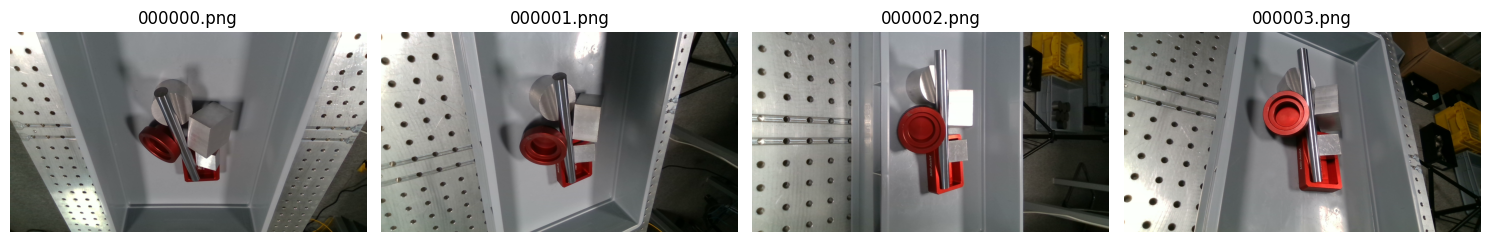

In [ ]:
# Once downloaded, you can visualize a few images from it directly!
visualize_subset_from_tar("/content/DIMO_archives/real_d415.tar", num_images=4)

## Upzip

### dimo-small

In [34]:
!tar -xf /content/drive/MyDrive/UAM/Magisterka/CV_Project_DIMO/dimo_small.tar -C /content

Streaming output truncated to the last 5000 lines.
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar

In [ ]:
!tar -xf /content/DIMO_archives/dimo_small.tar -C /content

### Full-size (HD) real data

In [ ]:
!tar -xf /content/DIMO_archives/dimo.tar -C /content

tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'SCHILY.fflags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.FinderInfo'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.quarantine'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.metadata:_kMDItemUserTags'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.lastuseddate#PS'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.macl'
tar: Ignoring unknown extended header keyword 'LIBARCHIVE.xattr.com.apple.mac

In [ ]:
!tar -xf /content/DIMO_archives/real_d415.tar -C /content/dimo

## Step 6: Parse Annotations and Visualize Ground Truth
Let's load an image from `000300` and overlay the bounding boxes defined in the JSON files. This will serve as the foundation for our PyTorch Dataset later.

In [ ]:
# We will use trimesh to easily load the 3D .ply models
!pip install trimesh

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 7.9 MB/s eta 0:00:00


### Step 7: Load Dataset using Official DIMO Loader
Instead of parsing JSONs manually, let's use the provided `dimo_loader.py` to structure the dataset.

In [ ]:
!git clone https://github.com/pderoovere/dimo.git /content/dimo_repo

Cloning into '/content/dimo_repo'...
remote: Enumerating objects: 221, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (123/123), done.
remote: Total 221 (delta 88), reused 185 (delta 61), pack-reused 0 (from 0)
Receiving objects: 100% (221/221), 6.44 MiB | 6.37 MiB/s, done.
Resolving deltas: 100% (88/88), done.


In [35]:
import sys
import os
# Ensure the current directory is in the path to import dimo_loader
if '/content' not in sys.path:
    sys.path.append('/content')

from dimo_repo.scripts.dimo_loader import DimoLoader
from pathlib import Path

In [36]:
# Set path to the extracted dimo dataset folder
dimo_ds_path = Path('/content/dimo_small')

In [37]:
dimo_loader = DimoLoader()

# Pass cameras=["real_d415"] to specify the folder to load instead of defaulting to real_jaigo
dimo_ds = dimo_loader.load(dimo_ds_path,
                           cameras=[
                               "real_d415",
                               "real_jaigo",
                               "real_l515",
                               "real_mvbluefox",
                               "sim_jaigo"
                            ]
                           )

Loading real_d415
Loading real_jaigo
Loading real_l515
Loading real_mvbluefox
Loading sim_jaigo


In [38]:
# Let's inspect what was loaded
print("\n--- Dataset Summary ---")
print("Top-level keys:", list(dimo_ds.keys()))
print(f"Number of 3D models loaded: {len(dimo_ds['models'])}")

# Now the data will be keyed as 'real_d415' and we know it's a list of scenes
real_scenes = dimo_ds['real_d415']

print(f"Number of scenes in 'real_d415': {len(real_scenes)}")

first_scene = real_scenes[0]
print(f"Scene ID {first_scene['id']} contains {len(first_scene['images'])} images.")

# Let's look at the first image's keys
first_img = first_scene['images'][0]
print(f"First image keys: {list(first_img.keys())}")
print(f"Number of objects in first image: {len(first_img['objects'])}")


--- Dataset Summary ---
Top-level keys: ['models', 'real_d415', 'real_jaigo', 'real_l515', 'real_mvbluefox', 'sim_jaigo']
Number of 3D models loaded: 6
Number of scenes in 'real_d415': 600
Scene ID 000000 contains 13 images.
First image keys: ['id', 'path', 'camera', 'scene_info', 'objects']
Number of objects in first image: 1


In [82]:
dimo_ds['sim_jaigo'][0]['images'][1]

{'id': 1,
 'path': PosixPath('/content/dimo_small/sim_jaigo/000000_00/rgb/000001.png'),
 'camera': {'K': array([[311.43554688,   0.        , 162.67140198],
         [  0.        , 308.14028931, 126.34316254],
         [  0.        ,   0.        ,   1.        ]]),
  'cam_2world': array([[-8.82306695e-01, -1.39279366e-02, -4.70468998e-01,
           1.94388611e+02],
         [ 2.11766765e-01,  8.80930424e-01, -4.23221946e-01,
           1.80186905e+02],
         [ 4.20345068e-01, -4.73041058e-01, -7.74301291e-01,
           3.28259094e+02],
         [ 0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
           1.00000000e+00]])},
 'scene_info': {'light': 'lightRoomImage_hdr',
  'carrier': 0,
  'parts': 1,
  'viewpoint': 1,
  'exposure': 11,
  'environment_rotation': 0},
 'objects': [{'id': 1,
   'model_2cam': array([[-4.20344532e-01,  5.42555630e-01, -7.27285385e-01,
            7.49794388e+00],
          [ 4.73040938e-01,  8.15026641e-01,  3.34610224e-01,
           -1.32610817e+01],
 

Visualizing samples using DimoLoader structure...


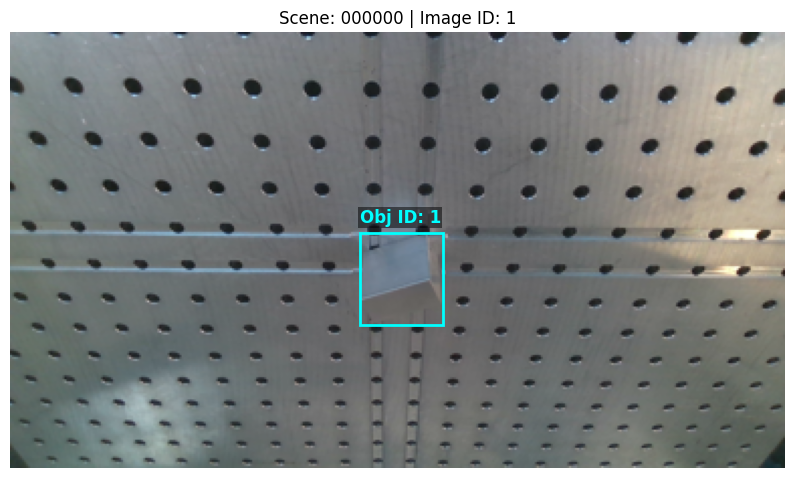

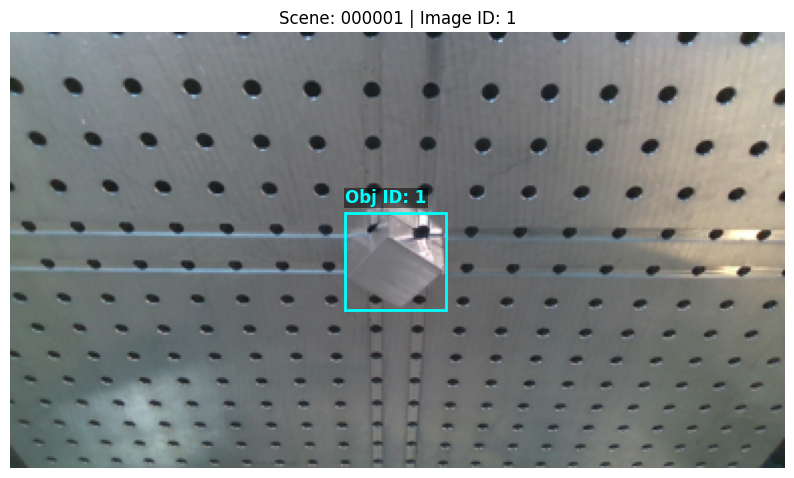

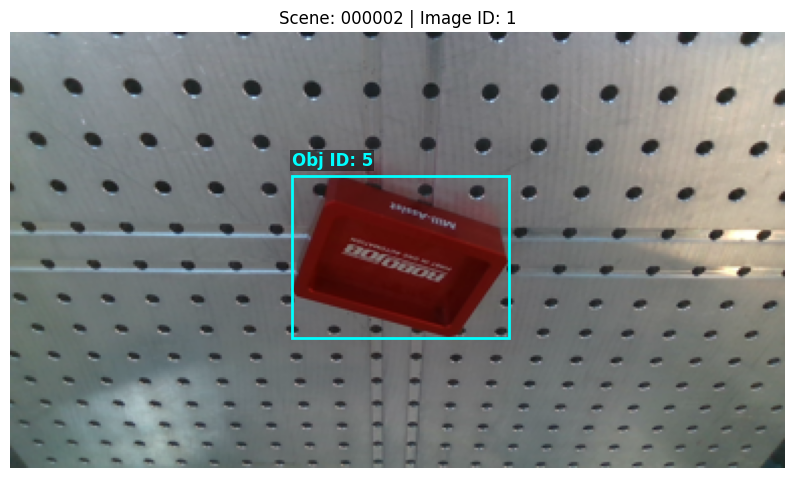

In [45]:
import numpy as np
import trimesh
import os
import matplotlib.pyplot as plt
from PIL import Image
import matplotlib.patches as patches

# Cache for 3D models to speed up projection across multiple images
models_dir = dimo_ds_path / "models"
models_cache = {}

def get_model_vertices(obj_id):
    if obj_id not in models_cache:
        model_path = os.path.join(models_dir, f"obj_{int(obj_id):06d}.ply")
        mesh = trimesh.load(model_path)
        models_cache[obj_id] = mesh.vertices
    return models_cache[obj_id]

def visualize_loaded_sample(scene, img_idx=0):
    # Extract image metadata from the loader's structure
    img_data = scene['images'][img_idx]
    img_path = img_data['path']

    img = Image.open(img_path)
    fig, ax = plt.subplots(1, figsize=(10, 8))
    ax.imshow(img)

    # Camera intrinsics matrix
    K = np.array(img_data['camera']['K']).reshape(3, 3)

    # Iterate through objects present in the image
    for obj in img_data['objects']:
        obj_id = obj['id']

        if 'model_2cam' in obj:
            pose = np.array(obj['model_2cam'])
            # Extract 3x3 Rotation and 3x1 translation from 4x4 matrix
            R = pose[:3, :3]
            t = pose[:3, 3].reshape(3, 1)
        else:
            print("No model_2cam found for object:", obj_id)
            continue

        # Load 3D vertices
        vertices = get_model_vertices(obj_id)

        # Project 3D points to 2D image plane
        pts_cam = (R @ vertices.T) + t
        pts_2d = K @ pts_cam

        # Normalize by depth (Z) to get pixel coordinates
        u = pts_2d[0, :] / pts_2d[2, :]
        v = pts_2d[1, :] / pts_2d[2, :]

        xmin, xmax = np.min(u), np.max(u)
        ymin, ymax = np.min(v), np.max(v)
        width, height = xmax - xmin, ymax - ymin

        # Draw the computed bounding box
        rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='cyan', facecolor='none')
        ax.add_patch(rect)
        ax.text(xmin, ymin - 5, f"Obj ID: {obj_id}", color='cyan', fontsize=12, fontweight='bold',
                bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

    plt.title(f"Scene: {scene['id']} | Image ID: {img_data['id']}")
    plt.axis('off')
    plt.show()

# Let's visualize the first image from the first 3 scenes to verify
print("Visualizing samples using DimoLoader structure...")
for i in range(min(3, len(real_scenes))):
    visualize_loaded_sample(real_scenes[i], img_idx=0)

# Task
Implement a basic 6D object pose estimation pipeline on the DIMO dataset using PyTorch. This includes creating a PyTorch Dataset using the DimoLoader, defining a lightweight ResNet-based baseline model for pose estimation, writing a training loop for 5 epochs, and visualizing the model's predictions.

## Create PyTorch Dataset

Implement a PyTorch Dataset class to load a subset of the real DIMO data, returning images, bounding boxes, and 6D pose annotations.


In [46]:
import torch
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as transforms
import numpy as np
from PIL import Image
import cv2

class DimoDataset(Dataset):
    def __init__(self, scenes, max_samples=1000):
        self.samples = []
        self.target_size = (224, 224)
        self.transform = transforms.Compose([
            transforms.Resize(self.target_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
        ])

        count = 0
        for scene in scenes:
            for img_data in scene['images']:
                img_path = img_data['path']
                K = np.array(img_data['camera']['K']).reshape(3, 3)
                for obj in img_data['objects']:
                    if 'model_2cam' in obj:
                        self.samples.append({
                            'img_path': img_path,
                            'K': K,
                            'obj_id': obj['id'],
                            'pose': np.array(obj['model_2cam'])
                        })
                        count += 1
                        if count >= max_samples:
                            return

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        img = Image.open(sample['img_path']).convert('RGB')
        orig_w, orig_h = img.size

        pose = sample['pose']
        R = pose[:3, :3]
        t = pose[:3, 3]

        # Scale camera intrinsics to match the new image size (224x224)
        K = sample['K'].copy()
        target_w, target_h = self.target_size
        scale_x = target_w / orig_w
        scale_y = target_h / orig_h

        K[0, :] *= scale_x
        K[1, :] *= scale_y

        # Transform applies resizing to 224x224, tensor conversion, and normalization
        img_tensor = self.transform(img)

        return img_tensor, torch.tensor(R, dtype=torch.float32), torch.tensor(t, dtype=torch.float32), torch.tensor(K, dtype=torch.float32)

print("Initializing dataset...")
train_dataset = DimoDataset(real_scenes, max_samples=1000)
print(f"Created dataset with {len(train_dataset)} samples.")
# Test fetching a sample
img_t, R_t, t_t, K_t = train_dataset[0]
print("Image tensor shape:", img_t.shape)
print("Rotation shape:", R_t.shape)
print("Translation shape:", t_t.shape)
print("Scaled K shape:", K_t.shape)


Initializing dataset...
Created dataset with 1000 samples.
Image tensor shape: torch.Size([3, 224, 224])
Rotation shape: torch.Size([3, 3])
Translation shape: torch.Size([3])
Scaled K shape: torch.Size([3, 3])


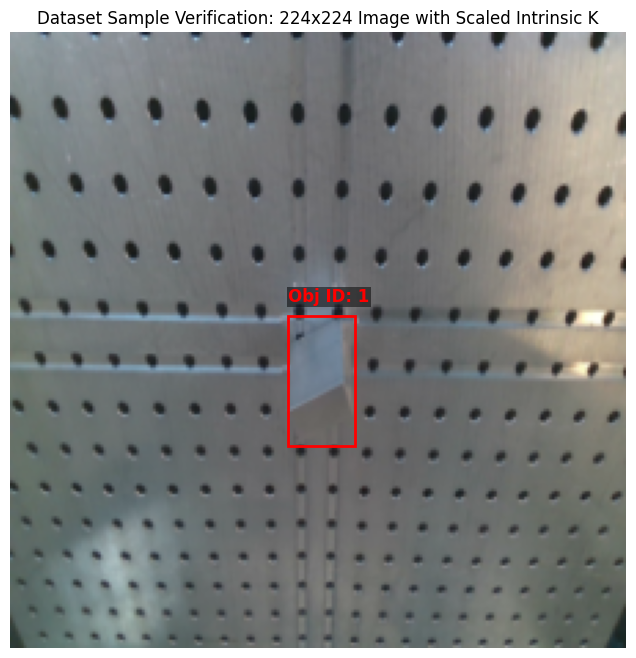

In [47]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import torch
import numpy as np

# 1. Fetch the first sample from our dataset
sample_idx = 0
img_t, R_t, t_t, K_t = train_dataset[sample_idx]
obj_id = train_dataset.samples[sample_idx]['obj_id']

# 2. Un-normalize the image tensor for visualization
mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
img_display = img_t * std + mean
# Convert to numpy (H, W, C) and clip values to valid range [0, 1]
img_display = img_display.numpy().transpose(1, 2, 0)
img_display = np.clip(img_display, 0, 1)

# 3. Convert poses and camera matrices to numpy arrays
R = R_t.numpy()
t = t_t.numpy().reshape(3, 1)
K = K_t.numpy()

# 4. Get the 3D vertices for this object
vertices = get_model_vertices(obj_id)

# 5. Project the 3D vertices to 2D image coordinates
# Transform to camera coordinates
pts_cam = (R @ vertices.T) + t
# Project using the SCALED intrinsic matrix
pts_2d = K @ pts_cam

# Normalize by depth (Z) to get pixel coordinates
u = pts_2d[0, :] / pts_2d[2, :]
v = pts_2d[1, :] / pts_2d[2, :]

# Get bounding box extents
xmin, xmax = np.min(u), np.max(u)
ymin, ymax = np.min(v), np.max(v)
width, height = xmax - xmin, ymax - ymin

# 6. Plot the image and the projected bounding box
fig, ax = plt.subplots(1, figsize=(8, 8))
ax.imshow(img_display)

rect = patches.Rectangle((xmin, ymin), width, height, linewidth=2, edgecolor='red', facecolor='none')
ax.add_patch(rect)
ax.text(xmin, ymin - 5, f"Obj ID: {obj_id}", color='red', fontsize=12, fontweight='bold',
        bbox=dict(facecolor='black', alpha=0.5, edgecolor='none', pad=1))

plt.title("Dataset Sample Verification: 224x224 Image with Scaled Intrinsic K")
plt.axis('off')
plt.show()


## Dataset insights

In [ ]:
import pandas as pd

# Prepare a list to hold all the flattened records
records = []

print("Extracting records from dimo_ds...")
# Iterate through the top-level keys (cameras and 'models')
for cam_name, scenes in dimo_ds.items():
    if cam_name == 'models':
        continue # Skip the 3D models metadata for the main dataframe

    for scene in scenes:
        scene_id = scene['id']
        for img in scene['images']:
            img_id = img['id']
            img_path = str(img['path'])
            num_objects = len(img['objects'])

            image_data = {
                    'camera': cam_name,
                    'scene_id': scene_id,
                    'image_id': img_id,
                    'image_path': img_path,
                    'total_objects_in_image': num_objects
                }
            # Use .get() to safely handle cases where scene_info might be missing
            image_data.update(img.get('scene_info', {}))

            for obj in img['objects']:
                # Crucial: make a copy so we don't overwrite previous objects from the same image
                obj_record = image_data.copy()
                obj_record['object_id'] = obj['id']

                records.append(obj_record)

# Create the DataFrame
df_dimo = pd.DataFrame(records)

In [72]:
import pandas as pd

# Group by the specified columns and count occurrences
# dropna=False ensures we don't drop rows where fields like 'exposure' are NaN (e.g., real images)
grouped_counts = df_dimo.groupby(
    ['light', 'exposure', 'environment_rotation', 'carrier'],
    dropna=False
).size().reset_index(name='count')

# Sort by count descending to see the most common configurations
grouped_counts = grouped_counts.sort_values(by='count', ascending=False)

print(f"Total unique combinations: {len(grouped_counts)}")
display(grouped_counts.head(20))

Total unique combinations: 30239


,light,exposure,environment_rotation,carrier,count
16209,lightRoomImage_hdr,11.000000,0.000000,2,135837
16207,lightRoomImage_hdr,11.000000,0.000000,0,105456
10526,darkRoomImage_hdr,7.000000,180.000000,1,95472
10525,darkRoomImage_hdr,7.000000,180.000000,0,95056
16208,lightRoomImage_hdr,11.000000,0.000000,1,94900
10528,darkRoomImage_hdr,9.500000,180.000000,2,48360
10527,darkRoomImage_hdr,7.000000,180.000000,2,45656
0,0,NaN,NaN,0,26364
1,0,NaN,NaN,1,23972
2,0,NaN,NaN,2,23868


In [76]:
df_dimo.groupby(
    ['light'],
    dropna=False
).size().reset_index(name='count').sort_values(by='count', ascending=False)

,light,count
20,lightRoomImage_hdr,336193
13,darkRoomImage_hdr,284544
0,0,74204
1,1,71136
9,blinds_4k,58149
3,abandoned_games_room_01_4k,57837
10,boiler_room_4k,57824
6,artist_workshop_4k,57811
4,abandoned_workshop_4k,57746
7,auto_service_4k,57655


## Split dataset into

> Para trenuje ten sam model na różnych reżimach danych: tylko dane rzeczywiste, tylko dane syntetyczne, słaba randomizacja syntetyczna, silna randomizacja syntetyczna i mieszanka danych



In [78]:
import pandas as pd

# 1. Tylko dane rzeczywiste (Only real data)
df_real_only = df_dimo[df_dimo['camera'].str.startswith('real')].copy()

# 2. Tylko dane syntetyczne (All synthetic data)
df_sim_all = df_dimo[df_dimo['camera'] == 'sim_jaigo'].copy()

# Helper to identify 'Real-world lighting' in simulation
real_world_lights = ['lightRoomImage_hdr', 'darkRoomImage_hdr']

# 3. Słaba randomizacja syntetyczna (Weak randomization)
# We'll use simulation data with real-world lighting environments (allowing default rotations)
df_sim_weak_dr = df_sim_all[
    df_sim_all['light'].isin(real_world_lights)
].copy()

# 4. Silna randomizacja syntetyczna (Strong randomization)
# Simulation data with random HDRI lighting and random rotations
df_sim_strong_dr = df_sim_all[
    ~df_sim_all['light'].isin(real_world_lights)
].copy()

# 5. Mieszanka danych (Mixed data)
# To create a balanced 50/50 split without duplicating data on disk,
# we sample the larger dataset to match the size of the smaller one.
min_size = min(len(df_real_only), len(df_sim_strong_dr))
df_mixed = pd.concat([
    df_real_only.sample(n=min_size, random_state=42),
    df_sim_strong_dr.sample(n=min_size, random_state=42)
], ignore_index=True)

print("--- Dataset Splits for the Project ---")
print(f"1. Tylko dane rzeczywiste:       {len(df_real_only)} observations")
print(f"2. Tylko dane syntetyczne (all): {len(df_sim_all)} observations")
print(f"3. Słaba randomizacja:           {len(df_sim_weak_dr)} observations")
print(f"4. Silna randomizacja:           {len(df_sim_strong_dr)} observations")
print(f"5. Mieszanka danych (Real+Strong): {len(df_mixed)} observations (50% Real / 50% Sim)")


--- Dataset Splits for the Project ---
1. Tylko dane rzeczywiste:       145340 observations
2. Tylko dane syntetyczne (all): 2443597 observations
3. Słaba randomizacja:           620737 observations
4. Silna randomizacja:           1822860 observations
5. Mieszanka danych (Real+Strong): 290680 observations (50% Real / 50% Sim)


These splits are now ready to be used as indices to feed into your `DimoDataset` PyTorch class. You can just pass the specific subset of `scene_id` and `image_id` combinations from these dataframes during the initialization of your `DataLoader` for each training regime!

## Helper: 6D Continuous Rotation to 3x3 Matrix
Implementation of the Gram-Schmidt process for 6D rotation representations (Zhou et al., CVPR 2019). The network predicts 6 values, and this function converts them into a valid 3x3 rotation matrix.

In [84]:
import torch.nn.functional as F

def ortho6d_to_rotation_matrix(poses_6d):
    """
    Gram-Schmidt
    Converts a batch of 6D continuous rotation representations to 3x3 rotation matrices.
    Expects input shape: (batch_size, 6)
    Returns output shape: (batch_size, 3, 3)
    """
    # Split the 6D vector into two 3D vectors
    x_raw = poses_6d[:, 0:3]
    y_raw = poses_6d[:, 3:6]

    # 1. Normalize the first vector to get the X-axis
    x = F.normalize(x_raw, p=2, dim=-1)

    # 2. Make the second vector orthogonal to the X-axis (Gram-Schmidt process)
    # Subtract the projection of y_raw onto x
    y = y_raw - (torch.sum(x * y_raw, dim=-1, keepdim=True) * x)

    # 3. Normalize the orthogonalized second vector to get the Y-axis
    y = F.normalize(y, p=2, dim=-1)

    # 4. The Z-axis is the cross product of X and Y
    z = torch.cross(x, y, dim=-1)

    # Stack the axes as columns to form the 3x3 rotation matrix
    # x, y, z are (batch_size, 3). Stacking along dim=-1 gives (batch_size, 3, 3)
    matrix = torch.stack([x, y, z], dim=-1)

    return matrix

# Quick test to verify it works
dummy_network_output = torch.randn(2, 6) # Batch of 2 random 6D vectors
rot_matrices = ortho6d_to_rotation_matrix(dummy_network_output)
print("Network output shape:", dummy_network_output.shape)
print("Rotation matrix shape:", rot_matrices.shape)
print("\nSample generated matrix (should be orthogonal):\n", rot_matrices[0])


Network output shape: torch.Size([2, 6])
Rotation matrix shape: torch.Size([2, 3, 3])

Sample generated matrix (should be orthogonal):
 tensor([[ 0.5626, -0.6148, -0.5527],
        [ 0.7055,  0.7056, -0.0667],
        [ 0.4309, -0.3524,  0.8307]])


## Define the Neural Network Model
We use a lightweight ResNet-18 pre-trained on ImageNet as our feature extractor. The final classification head is replaced with a linear layer that outputs exactly 9 continuous values (6 for rotation, 3 for translation).

In [85]:
import torch
import torch.nn as nn
from torchvision.models import resnet18, ResNet18_Weights

class PoseEstimationModel(nn.Module):
    def __init__(self, pretrained=True):
        super().__init__()
        # Load pre-trained ResNet-18 for faster convergence and better feature extraction
        weights = ResNet18_Weights.DEFAULT if pretrained else None
        self.backbone = resnet18(weights=weights)

        # The original fully connected layer outputs 1000 classes (for ImageNet)
        # We replace it to output exactly 9 values:
        # 6 for continuous rotation representation + 3 for 3D translation
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, 9)

    def forward(self, x):
        # Forward pass through the modified ResNet
        out = self.backbone(x) # Shape: (batch_size, 9)

        # Split the output into the 6D rotation vector and the 3D translation vector
        rotation_6d = out[:, :6]
        translation_3d = out[:, 6:]

        return rotation_6d, translation_3d

# Quick test to verify the model structure and tensor shapes
dummy_input = torch.randn(2, 3, 224, 224) # Batch of 2 standard RGB images
model = PoseEstimationModel(pretrained=True)
rot_6d_out, trans_3d_out = model(dummy_input)

print("Input image shape:", dummy_input.shape)
print("Predicted 6D Rotation shape:", rot_6d_out.shape)
print("Predicted 3D Translation shape:", trans_3d_out.shape)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 118MB/s]


Input image shape: torch.Size([2, 3, 224, 224])
Predicted 6D Rotation shape: torch.Size([2, 6])
Predicted 3D Translation shape: torch.Size([2, 3])


## Training Loop & Loss Function
Here we define the training pipeline. The total loss is the sum of:
1. **Rotation Loss (L1):** The absolute difference between our predicted 3x3 matrix (via the Gram-Schmidt helper) and the ground truth 3x3 matrix.
2. **Translation Loss (L1):** The absolute difference between the predicted X, Y, Z translation and the ground truth.

We will train the baseline model for 5 epochs.

In [ ]:
import torch.optim as optim
from torch.utils.data import DataLoader
import time

# 1. Setup Device, DataLoader, Model, and Optimizer
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Create a DataLoader for batching and shuffling
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)

# Instantiate model and move to GPU
model = PoseEstimationModel(pretrained=True).to(device)

# Using Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-4)

# Define loss function (L1 is often more robust to outliers in pose estimation than MSE)
criterion = torch.nn.L1Loss()

# 2. Training Loop
num_epochs = 5

print("Starting training...")
for epoch in range(num_epochs):
    model.train()  # Set model to training mode

    running_loss = 0.0
    running_loss_rot = 0.0
    running_loss_trans = 0.0

    start_time = time.time()

    for i, (images, gt_R, gt_t, _) in enumerate(train_loader):
        # Move data to GPU
        images = images.to(device)
        gt_R = gt_R.to(device)
        gt_t = gt_t.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass
        pred_rot_6d, pred_t = model(images)

        # Convert predicted 6D rotation to 3x3 rotation matrix
        pred_R_matrix = ortho6d_to_rotation_matrix(pred_rot_6d)

        # Calculate Losses
        loss_rot = criterion(pred_R_matrix, gt_R)
        loss_trans = criterion(pred_t, gt_t)

        # Total loss (you can weigh these differently if scale varies drastically)
        loss = loss_rot + loss_trans

        # Backward pass and optimize
        loss.backward()
        optimizer.step()

        # Accumulate statistics
        running_loss += loss.item()
        running_loss_rot += loss_rot.item()
        running_loss_trans += loss_trans.item()

    # Calculate epoch metrics
    epoch_time = time.time() - start_time
    num_batches = len(train_loader)
    avg_loss = running_loss / num_batches
    avg_loss_rot = running_loss_rot / num_batches
    avg_loss_trans = running_loss_trans / num_batches

    print(f"Epoch [{epoch+1}/{num_epochs}] - Time: {epoch_time:.2f}s | "
          f"Total Loss: {avg_loss:.4f} (Rot: {avg_loss_rot:.4f}, Trans: {avg_loss_trans:.4f})")

print("Training completed!")

Using device: cpu
Starting training...
